In [3]:
from google.colab import files
import pandas as pd
uploaded = files.upload()  # a button will appear — click it and select AllProductReviews.csv

df = pd.read_csv('AllProductReviews.csv')
print(df.head())

Saving AllProductReviews.csv to AllProductReviews.csv
                                        ReviewTitle  \
0             Honest review of an edm music lover\n   
1             Unreliable earphones with high cost\n   
2                        Really good and durable.\n   
3                 stopped working in just 14 days\n   
4  Just Awesome Wireless Headphone under 1000...😉\n   

                                          ReviewBody  ReviewStar  \
0  No doubt it has a great bass and to a great ex...           3   
1  This  earphones are unreliable, i bought it be...           1   
2  i bought itfor 999,I purchased it second time,...           4   
3  Its sound quality is adorable. overall it was ...           1   
4  Its Awesome... Good sound quality & 8-9 hrs ba...           5   

            Product  
0  boAt Rockerz 255  
1  boAt Rockerz 255  
2  boAt Rockerz 255  
3  boAt Rockerz 255  
4  boAt Rockerz 255  


In [9]:
print("Shape:", df.shape)
print()
print(df.head(10))

Shape: (14337, 3)

                                          ReviewBody  ReviewStar  label
0  No doubt it has a great bass and to a great ex...           3      1
1  This  earphones are unreliable, i bought it be...           1      0
2  i bought itfor 999,I purchased it second time,...           4      2
3  Its sound quality is adorable. overall it was ...           1      0
4  Its Awesome... Good sound quality & 8-9 hrs ba...           5      2
5  After 11 days, the charging port isn't working...           1      0
6  Sound-4.5/5Build quality-4.5/5Battery life -4/...           4      2
7  After one month usage reviewing this .Pros-1- ...           3      1
8  I can’t get enough of this earphone! The bass ...           5      2
9  The product durability is 1 month..I just lost...           1      0


In [4]:
#to keep columns we need
df = df[['ReviewBody', 'ReviewStar']].dropna()

#to convert star ratings to sentiment labels
def get_label(star):
    if star <= 2:
        return 0  # negative
    elif star == 3:
        return 1  # neutral
    else:
        return 2  # positive

df['label'] = df['ReviewStar'].apply(get_label)

print(df['label'].value_counts())

label
2    9402
0    3432
1    1503
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X = df['ReviewBody']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          #to keep class balance the same in both the splits
)

In [6]:
#TRAINING THE MODEL
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

#1. convert text to numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

#2 train the model
model = LinearSVC()
model.fit(X_train_vec, y_train)

LinearSVC()

In [7]:
#RESULTS
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print()
print(classification_report(
    y_test, y_pred,
    target_names=['negative', 'neutral', 'positive']
))

Accuracy: 0.8

              precision    recall  f1-score   support

    negative       0.74      0.78      0.76       686
     neutral       0.27      0.11      0.16       301
    positive       0.86      0.92      0.89      1881

    accuracy                           0.80      2868
   macro avg       0.62      0.60      0.60      2868
weighted avg       0.77      0.80      0.78      2868



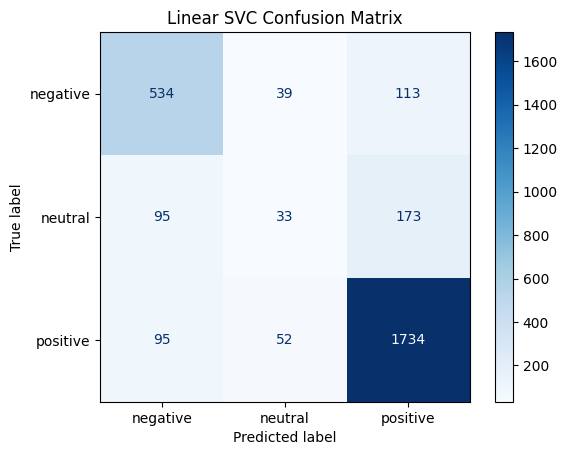

In [8]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['negative', 'neutral', 'positive'],
    cmap='Blues'
)
plt.title('Linear SVC Confusion Matrix')
plt.show()